<a href="https://colab.research.google.com/github/benlebosss/Adaltas-ECE-2026/blob/main/wikistream_pyspark_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 - Structured Streaming (version Google Colab)
Adaptation du TP `lab_docker_wikistreams` (ECE Big Data Processing, Fall 2026).

Colab n'offre ni Docker ni Kafka. Le pipeline est donc adapté : le *producer* (thread Python) lit le flux SSE de Wikimedia et écrit des fichiers JSON dans un dossier, et Spark Structured Streaming lit ce dossier avec le *file source* (à la place du topic Kafka `wikistreams`). Le reste (schéma, fenêtres, agrégations) reste identique au TP.

In [ ]:
!pip -q install pyspark==3.5.1 requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [ ]:
import json, os, shutil, threading, time
import requests
from datetime import datetime, timedelta
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, window, count, avg, sum as _sum, max as _max
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, BooleanType

spark = (SparkSession.builder.appName("WikiStructuredStreaming")
         .config("spark.sql.shuffle.partitions", "4").getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(spark.version)

3.5.1


## 1. Producer (remplace `wikistream_producer.py` + Kafka)
Filtres configurables : `SERVER_NAME` (ex. `fr.wikipedia.org`, `en.wikipedia.org`) et `EVENT_TYPE`.

In [ ]:
INPUT_DIR = "/content/wikistreams"
shutil.rmtree(INPUT_DIR, ignore_errors=True); os.makedirs(INPUT_DIR)

SERVER_NAME = "fr.wikipedia.org"   # filtre producer : changer de langue ici
EVENT_TYPE  = "edit"
URL = "https://stream.wikimedia.org/v2/stream/recentchange"
HEADERS = {"User-Agent": "ECE-BigData-Lab/1.0 (student lab)", "Accept": "text/event-stream"}

stop_event = threading.Event()
stats = {"seen": 0, "kept": 0}

def producer(duration_min=10, flush_every=5):
    stop_at = datetime.now() + timedelta(minutes=duration_min)
    buf, last, n = [], time.time(), 0
    with requests.get(URL, headers=HEADERS, stream=True, timeout=60) as r:
        for line in r.iter_lines():
            if stop_event.is_set() or datetime.now() > stop_at: break
            if not line or not line.startswith(b"data: "): continue
            try: ev = json.loads(line[6:])
            except Exception: continue
            stats["seen"] += 1
            if ev.get("server_name") == SERVER_NAME and ev.get("type") == EVENT_TYPE:
                buf.append(json.dumps(ev)); stats["kept"] += 1
            if buf and time.time() - last >= flush_every:
                tmp = f"{INPUT_DIR}/.tmp_{n}"
                open(tmp, "w").write("\n".join(buf) + "\n")
                os.rename(tmp, f"{INPUT_DIR}/batch_{n:05d}.json")   # rename atomique
                buf, last, n = [], time.time(), n + 1

t = threading.Thread(target=producer, kwargs={"duration_min": 15}, daemon=True)
t.start()
time.sleep(20); print(stats, os.listdir(INPUT_DIR))

{'seen': 759, 'kept': 8} ['batch_00000.json', 'batch_00002.json', 'batch_00001.json']


## 2. Lecture en streaming et schéma

In [ ]:
schema = StructType([
    StructField("title", StringType()), StructField("user", StringType()),
    StructField("timestamp", LongType()), StructField("type", StringType()),
    StructField("wiki", StringType()), StructField("bot", BooleanType()),
    StructField("minor", BooleanType()), StructField("comment", StringType()),
    StructField("length", StructType([StructField("old", IntegerType()), StructField("new", IntegerType())])),
])

raw_df = spark.readStream.schema(schema).option("maxFilesPerTrigger", 5).json(INPUT_DIR)

events = (raw_df
    .withColumn("event_time", col("timestamp").cast("timestamp"))
    .withColumn("edit_size", col("length.new") - col("length.old"))
    .withWatermark("event_time", "10 minutes"))

## 3. Exploration A - fenêtres *tumbling* (1 min, sans chevauchement) : éditions par bot

In [ ]:
tumbling = (events
    .groupBy(window("event_time", "1 minute"), col("bot"))
    .agg(count("*").alias("edit_count"))
    .select(col("window.start").alias("window_start"), col("window.end").alias("window_end"), "bot", "edit_count"))

q_tumbling = (tumbling.writeStream.format("memory").queryName("tumbling")
              .outputMode("complete").start())

## 4. Exploration B - fenêtres *sliding* / chevauchantes (5 min toutes les 1 min)

In [ ]:
sliding = (events
    .groupBy(window("event_time", "5 minutes", "1 minute"), col("bot"))
    .agg(count("*").alias("edit_count"))
    .select(col("window.start").alias("window_start"), col("window.end").alias("window_end"), "bot", "edit_count"))

q_sliding = (sliding.writeStream.format("memory").queryName("sliding")
             .outputMode("complete").start())

## 5. Exploration C - taille des modifications (octets) par fenêtre de 2 min

In [ ]:
sizes = (events.filter(col("edit_size").isNotNull())
    .groupBy(window("event_time", "2 minutes"))
    .agg(count("*").alias("edits"), avg("edit_size").alias("avg_size"),
         _sum("edit_size").alias("net_bytes"), _max("edit_size").alias("biggest_add"))
    .select(col("window.start").alias("window_start"), "edits", "avg_size", "net_bytes", "biggest_add"))

q_sizes = (sizes.writeStream.format("memory").queryName("sizes")
           .outputMode("complete").start())

## 6. Exploration D - utilisateurs les plus actifs (hors bots)

In [ ]:
top_users = (events.filter(~col("bot"))
    .groupBy(window("event_time", "5 minutes"), col("user"))
    .agg(count("*").alias("edits")))

q_users = (top_users.writeStream.format("memory").queryName("top_users")
           .outputMode("complete").start())

## 7. Résultats (relancer cette cellule pour rafraîchir)

In [ ]:
time.sleep(90)   # laisser tourner quelques micro-batches
print(stats)
for q in (q_tumbling, q_sliding, q_sizes, q_users): print(q.name, q.status["message"])

print("\n== Tumbling 1 min ==")
spark.sql("SELECT * FROM tumbling ORDER BY window_start DESC, bot").show(20, False)
print("== Sliding 5 min / 1 min ==")
spark.sql("SELECT * FROM sliding ORDER BY window_start DESC, bot").show(20, False)
print("== Taille des edits (2 min) ==")
spark.sql("SELECT * FROM sizes ORDER BY window_start DESC").show(10, False)
print("== Top utilisateurs ==")
spark.sql("SELECT user, SUM(edits) edits FROM top_users GROUP BY user ORDER BY edits DESC").show(10, False)

{'seen': 4278, 'kept': 50}
tumbling Getting offsets from FileStreamSource[file:/content/wikistreams]
sliding Writing offsets to log
sizes Getting offsets from FileStreamSource[file:/content/wikistreams]
top_users Writing offsets to log

== Tumbling 1 min ==
+-------------------+-------------------+-----+----------+
|window_start       |window_end         |bot  |edit_count|
+-------------------+-------------------+-----+----------+
|2026-10-07 21:55:00|2026-10-07 21:56:00|false|10        |
|2026-10-07 21:55:00|2026-10-07 21:56:00|true |4         |
|2026-10-07 21:54:00|2026-10-07 21:55:00|false|17        |
|2026-10-07 21:54:00|2026-10-07 21:55:00|true |7         |
|2026-10-07 21:53:00|2026-10-07 21:54:00|false|6         |
|2026-10-07 21:53:00|2026-10-07 21:54:00|true |4         |
+-------------------+-------------------+-----+----------+

== Sliding 5 min / 1 min ==
+-------------------+-------------------+-----+----------+
|window_start       |window_end         |bot  |edit_count|
+----

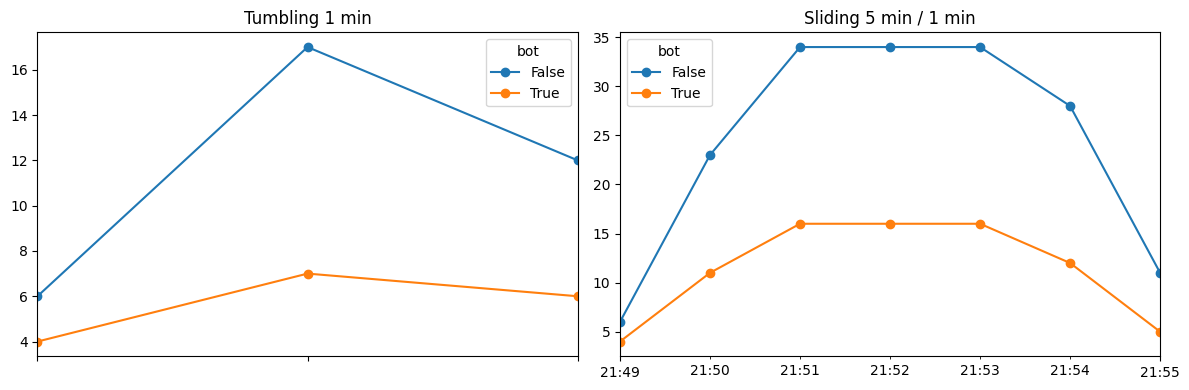

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
tm = spark.sql("SELECT window_start, bot, edit_count FROM tumbling").toPandas()
sl = spark.sql("SELECT window_start, bot, edit_count FROM sliding").toPandas()
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for a, df, title in ((ax[0], tm, "Tumbling 1 min"), (ax[1], sl, "Sliding 5 min / 1 min")):
    if len(df):
        df.pivot_table(index="window_start", columns="bot", values="edit_count", aggfunc="sum").sort_index().plot(ax=a, marker="o")
    a.set_title(title); a.set_xlabel("")
plt.tight_layout(); plt.show()

## 8. Arrêt propre
Pour changer de langue : modifier `SERVER_NAME`, relancer le producer (cellule 1) avec un autre dossier d'entrée ou après avoir vidé `INPUT_DIR`.

In [ ]:
stop_event.set()
for q in spark.streams.active: q.stop()
print("streams arrêtés")

streams arrêtés


## Conclusion
- **Tumbling** : fenêtres fixes et disjointes (chaque édition dans une seule fenêtre) → idéal pour un débit par minute.
- **Sliding** : fenêtre de 5 min glissant toutes les 1 min → chaque édition compte dans 5 fenêtres, courbe lissée.
- Le *watermark* de 10 min borne l'état gardé par Spark ; le filtre producer (`SERVER_NAME`) permet de suivre une autre langue.
- Adaptation Colab : pas de Kafka, remplacé par le file source de Spark (même API `readStream`).